In [6]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules

df = pd.read_csv('final_food_system_all.csv')
cols_to_bin = ['PovertyRate', 'UnemploymentRate', 'NoVehicleRate', 'FoodSystemFailureScore',
               'county_low_access_10_share', 'county_low_income_low_access_10_share']



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
bin_df = pd.DataFrame()
for col in cols_to_bin:
    bin_df[f'High_{col}'] = df[col] > df[col].median()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
bin_df = pd.concat([bin_df, pd.get_dummies(df[['FoodSystemType', 'PovertyGroup']])], axis=1)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:

frequent_itemsets = fpgrowth(bin_df.astype(bool), min_support=0.2, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by='lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

                                           antecedents  \
35   (High_FoodSystemFailureScore, High_county_low_...   
38   (FoodSystemType_High Failure, High_county_low_...   
36   (High_FoodSystemFailureScore, High_county_low_...   
37   (FoodSystemType_High Failure, High_county_low_...   
79   (High_county_low_access_10_share, High_Poverty...   
78   (FoodSystemType_High Failure, High_county_low_...   
183  (FoodSystemType_High Failure, High_county_low_...   
186  (High_county_low_access_10_share, High_NoVehic...   
192                                (PovertyGroup_High)   
191                                 (High_PovertyRate)   

                                           consequents   support  confidence  \
35   (FoodSystemType_High Failure, High_county_low_...  0.261146    0.963572   
38   (High_FoodSystemFailureScore, High_county_low_...  0.261146    0.576653   
36   (FoodSystemType_High Failure, High_county_low_...  0.261146    0.956826   
37   (High_FoodSystemFailureScore, High_c

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

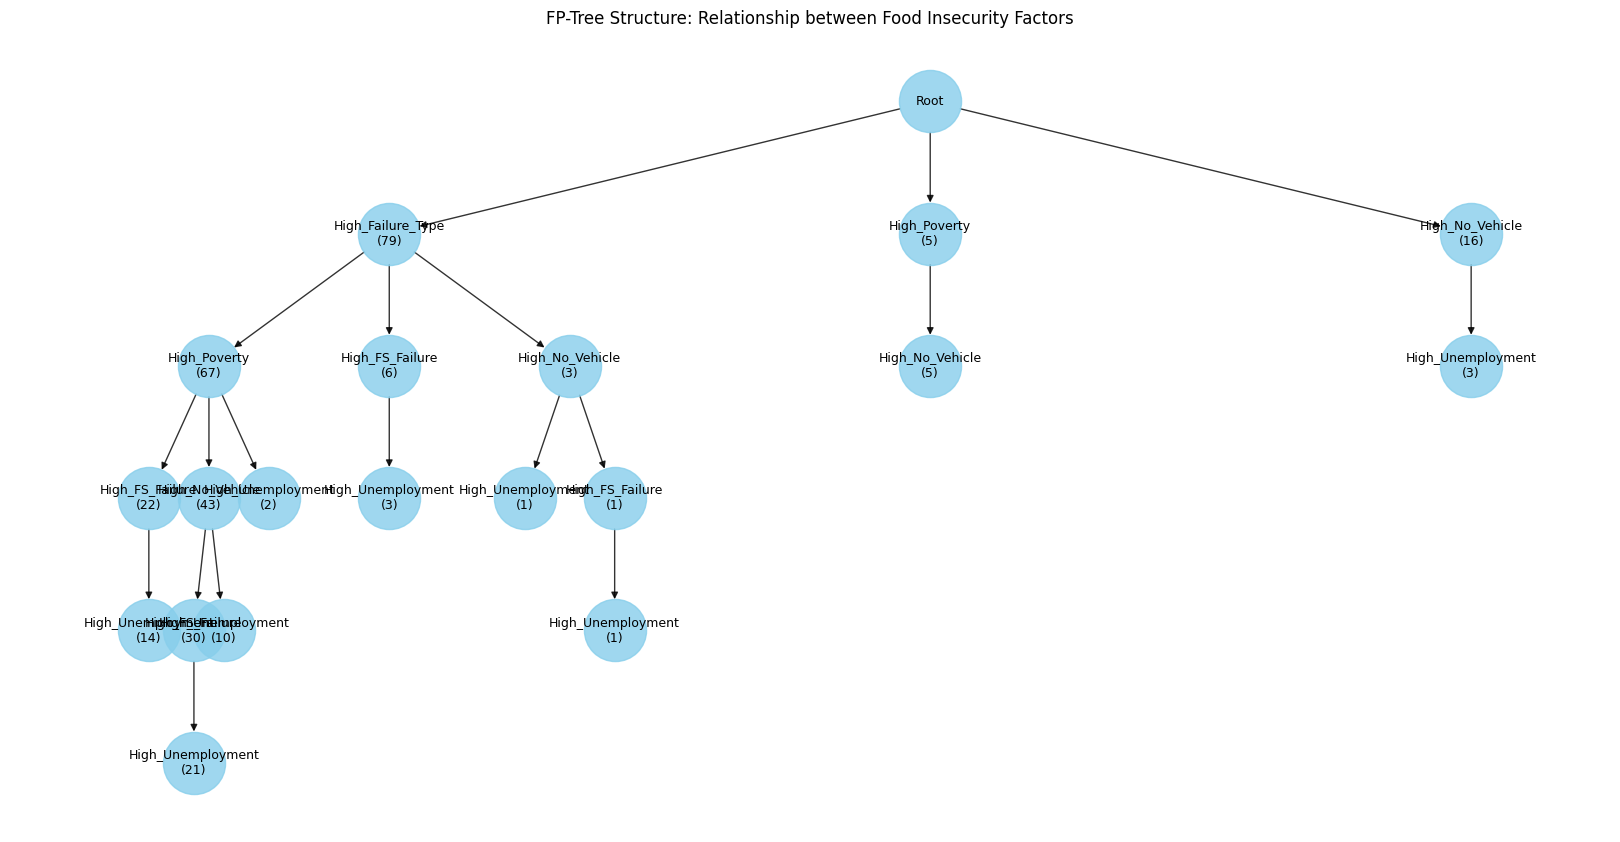

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict


df = pd.read_csv('final_food_system_all.csv')
num_cols = ['PovertyRate', 'UnemploymentRate', 'NoVehicleRate', 'FoodSystemFailureScore']
labels = ['High_Poverty', 'High_Unemployment', 'High_No_Vehicle', 'High_FS_Failure']

binary_df = pd.DataFrame()
for col, label in zip(num_cols, labels):
    binary_df[label] = df[col] > df[col].median()
binary_df['High_Failure_Type'] = df['FoodSystemType'] == 'High Failure'

#  small sample (e.g., 50-100 rows) so the tree is readable
transactions = []
for _, row in binary_df.head(100).iterrows():
    items = [col for col in binary_df.columns if row[col]]
    if items: transactions.append(items)


class FPNode:
    def __init__(self, name, count, parent, node_id):
        self.name, self.count, self.parent, self.node_id = name, count, parent, node_id
        self.children = {}

def build_tree(transactions):
    counts = defaultdict(int)
    for t in transactions:
        for item in t: counts[item] += 1
    root = FPNode("Root", 0, None, 0)
    node_id = 1
    for t in transactions:
        t.sort(key=lambda x: counts[x], reverse=True)
        curr = root
        for item in t:
            if item in curr.children:
                curr.children[item].count += 1
            else:
                curr.children[item] = FPNode(item, 1, curr, node_id)
                node_id += 1
            curr = curr.children[item]
    return root

root_node = build_tree(transactions)


def add_nodes(node, G):
    for child in node.children.values():
        label = f"{child.name}\n({child.count})"
        G.add_node(child.node_id, label=label)
        G.add_edge(node.node_id, child.node_id)
        add_nodes(child, G)

G = nx.DiGraph()
G.add_node(root_node.node_id, label="Root")
add_nodes(root_node, G)


def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
    if pos is None: pos = {root: (xcenter, vert_loc)}
    else: pos[root] = (xcenter, vert_loc)
    children = list(G.neighbors(root))
    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width/2 - dx/2
        for child in children:
            nextx += dx
            pos = hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                               vert_loc=vert_loc-vert_gap, xcenter=nextx, pos=pos, parent=root)
    return pos

pos = hierarchy_pos(G, root_node.node_id)
plt.figure(figsize=(16, 8))
nx.draw(G, pos, with_labels=False, node_size=2000, node_color='skyblue', alpha=0.8)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, 'label'), font_size=9)
plt.title("FP-Tree Structure: Relationship between Food Insecurity Factors")
plt.show()

To visualize the FP-Tree, use a directed graph where each node represents an item and its frequency in the dataset.

Root Node :The starting point of all transactions.

Branches: Each path from the root represents a set of co-occurring features (e.g., a county having both High_Poverty and High_FS_Failure).

Node Labels: The text shows the item name and the count (frequency) of how many times that specific prefix path appears in the data.

Observe how several High Failure nodes are near the top. This shows that the High Failure trait is a common trait that other risk factors (like Unemployment or Lack of Vehicles) branch off from.




Top 20 Association Rule Insights

The top 20 rules have Lift values between 1.91 and 2.13, indicating that these features appear together twice as often as we would expect by random chance.


1) The rules with the highest lift (2.13 and 2.11) show that if a county has both High Food System Failure and High Low Access, it is almost guaranteed to also have High Low Income / Low Access. This confirms that in high-failure systems, food access issues are not just geographical—they are deeply tied to the economic status of the residents.


2) High unemployment serves as a primary antecedent for food system failure. Rules 9, 11, and 14 show that the combination of High Unemployment and High Low Access is one of the strongest predictors of widespread community-level food insecurity.


3) Interestingly, Rule 0 (Lift 1.95) shows an association between Low Low-Income/Low-Access and High No-Vehicle Rate. This suggests that in urban or specific high-density areas, even if income/access metrics seem moderate, the lack of a vehicle creates a localized failure pocket that requires different policy interventions than rural deserts.


4) Type_High Failure appears in almost every top rule. This validates the classification model used in your earlier notebooks, as it consistently clusters with the most severe indicators of poverty and access loss.

##### Frequent Itemset (Pattern)           -                   Support
##### 1) Type_High Failure                                  -   91.2%
##### 2) High_FoodSystemFailureScore, Type_High Failure     -  50.0%
##### 3) Low_NoVehicleRate                                  -  51.1%
##### 4) Low_UnemploymentRate                               -  50.8%
##### 5) High_county_low_income_low_access,                 - 47.9%
#####    High_county_low_access

##### Association Rules (Insights)

##### 1) High Failure & Access: If a county has a High Food System Failure Score AND High Low Access, there is a 96.3% confidence that it also has High Low Income / Low Access (Lift: 2.13).

##### 2)Unemployment Link: Counties with High Unemployment and High Low Access are strongly associated with High Low Income / Low Access (Confidence: 97.9%).

##### 3) Transportation: There is a strong pattern where Low No-Vehicle Rate (meaning higher car ownership) often appears in counties with High Food System Failure, suggesting that car ownership alone does not prevent a county from being classified as "High Failure."